# SEARCH FOR S2 IMAGES

In this notebook we will look for S2 Images in the area of interest.

In [1]:
%load_ext autoreload
%autoreload 2

import earthaccess

from swot_toolkit.swot import auth_earthaccess, swot_results_to_df
from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.planetary import search_s2, s2_results_to_df


/workspaces/swot/.venv/lib/python3.12/site-packages/fastkml/config.py:39: UserWarning: Package `lxml` missing. Pretty print will be disabled
  warnings.warn("Package `lxml` missing. Pretty print will be disabled")  # noqa: B028


In [2]:
auth_earthaccess()

## Open the AOI

In [3]:
# Read geometry from a KML file
AOIs = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")

if AOIs is not None:
    AOI = AOIs[0]

## Search for SWOT images

In [4]:
# Search for products within the AOI and Time frame
results = earthaccess.search_data(
    short_name="SWOT_L2_HR_PIXC_2.0",
    temporal=(START_DATE, END_DATE),
    bounding_box=AOI.bounds,
)

swot_df = swot_results_to_df(results, drop_duplicates=True)

swot_df.head(3)

,cycle_id,pass_id,tile_id,date_str,tile_name,vers,item,datetime,date
short_id,,,,,,,,,
SWOT_L2_HR_PIXC_009_033_149R_20240105T072529,009,033,149R,20240105T072529,033_149R,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05
SWOT_L2_HR_PIXC_009_033_149L_20240105T072529,009,033,149L,20240105T072529,033_149L,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05
SWOT_L2_HR_PIXC_009_033_150R_20240105T072539,009,033,150R,20240105T072539,033_150R,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:39,2024-01-05


## Search Sentinel-2 on Planetary Computer

In [4]:
START_DATE = "2024-09-10"
END_DATE = "2024-09-30"

date_range = START_DATE + "/" + END_DATE
date_range

'2024-09-10/2024-09-30'

In [5]:
s2_results = search_s2(aoi=AOI, date_range=date_range, s2_tile="21MYS")
len(s2_results)


3

In [40]:
list(s2_results)

[<Item id=S2A_MSIL2A_20240927T135701_R067_T21MYS_20240927T190725>,
 <Item id=S2B_MSIL2A_20240922T135659_R067_T21MYS_20240922T194135>,
 <Item id=S2B_MSIL2A_20240912T140049_R067_T21MYS_20240912T193143>]

In [47]:
s2_results[0]

<Item id=S2A_MSIL2A_20240927T135701_R067_T21MYS_20240927T190725>

In [ ]:
import odc.stac
import planetary_computer as pc

import rioxarray as xrio
stac_url = "https://planetarycomputer.microsoft.com/api/stac/v1"

signed_item = pc.sign(s2_results[0])
cube = odc.stac.load(
    [signed_item],  # List of STAC items (can pass multiple)
    bands=["B04", "B03", "B02", "B08", "B11", "B12", "SCL"],  # Bands to load
    # crs="EPSG:4326",          # Output CRS
    resolution=10,  # Output pixel size (degrees)
    bbox=AOI.bounds,
    # chunks={},                # Set for Dask or use None
)
cube

In [12]:
# img = cube.to_array(dim="band").squeeze()/1e4

In [52]:
# img.plot.imshow(rgb="band", figsize=(10, 10), vmax=0.4)

In [13]:
cube = cube.squeeze()

In [58]:
cube.rio.to_raster("/data/swot/geotiffs/s2_curua-una-20240927T135701.tif", compression="DEFLATE")

In [61]:
cube.rio.reproject("epsg:4326").rio.to_raster(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_4326.tif",
    compression="DEFLATE",
)

## Create Water Mask

In [15]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray as xrio

### Open the Image

/workspaces/swot/.venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1584].


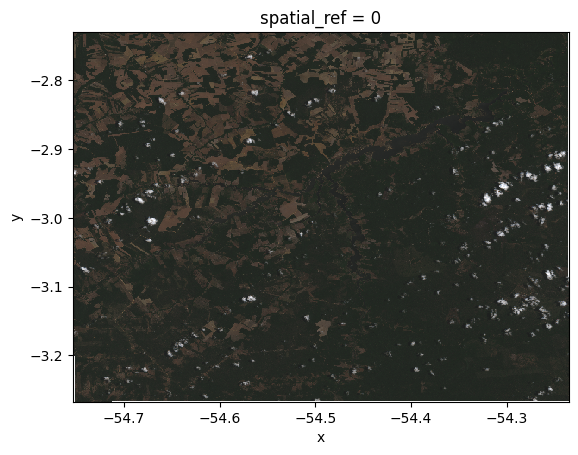

In [16]:
# Open the image as a cube
cube = xrio.open_rasterio("/data/swot/geotiffs/s2_curua-una-20240927T135701_4326.tif")
cube = cube.assign_coords({"band": ["B04", "B03", "B02", "B08", "B11", "B12", "SCL"]})

# Separate the SCL band
scl = cube.sel(band="SCL").astype("uint8")

# Select the bands of interest
img = cube.sel(band=[b for b in cube.band.values if b not in ["SCL"]])

img = (img / 1e4).astype("float32")  # Scale to reflectance

img.sel(band=["B04", "B03", "B02"], x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(rgb="band")

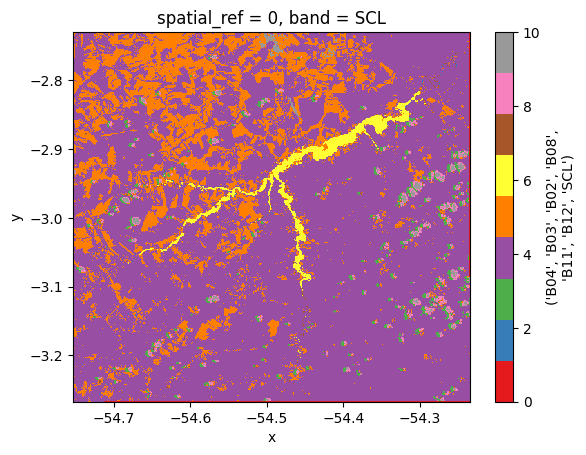

In [25]:
scl.sel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow(cmap="Set1", vmin=0, vmax=10)

In [5]:
img_df = img.to_dataframe("reflctance").reset_index().set_index(["x", "y"])
img_df

,,band,spatial_ref,reflctance
x,y,,,
-54.752837,-2.730384,B04,0,NaN
-54.752747,-2.730384,B04,0,NaN
-54.752656,-2.730384,B04,0,NaN
-54.752566,-2.730384,B04,0,NaN
-54.752476,-2.730384,B04,0,NaN
...,...,...,...,...
-54.235286,-3.266775,B12,0,NaN
-54.235196,-3.266775,B12,0,NaN
-54.235106,-3.266775,B12,0,NaN


In [9]:
img_df = img_df.drop(columns=["spatial_ref"])

In [15]:
# Then, combine into a wide format DataFrame with bands as columns
reflectances = pd.DataFrame()

for band in img_df["band"].unique():
    band_data = img_df[img_df["band"] == band].drop(columns=["band"])
    band_data = band_data.rename(columns = {"reflctance": band})
    reflectances = pd.concat([reflectances, band_data], axis=1)

# radiometry = radiometry.reset_index().set_index(["x", "y"])

reflectances

,,B04,B03,B02,B08,B11,B12
x,y,,,,,,
-54.752837,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN
-54.752747,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN
-54.752656,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN
-54.752566,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN
-54.752476,-2.730384,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
-54.235286,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN
-54.235196,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN
-54.235106,-3.266775,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
reflectances.to_parquet("/data/swot/geotiffs/points/s2_curua-una-reflectances_df.parquet")

In [24]:
assert img.shape[1] * img.shape[2] == len(reflectances)

In [25]:
del img_df

In [26]:
# Create a mapping to simplify the classes

scl_map = {
    0: 2,  # No data
    1: 2,  # No data
    2: 2,  # No data
    3: 2,  # Cloud / Shadow
    4: 0,  # No Water
    5: 0,  # No Water
    6: 1,  # Water
    7: 2,  # Cloud / Shadow
    8: 2,  # Cloud / Shadow
    9: 2,  # Cloud / Shadow
    10: 2,  # Cloud / Shadow
    11: 2,  # Cloud / Shadow
}

In [27]:
scl.data = np.vectorize(scl_map.get)(scl.values)

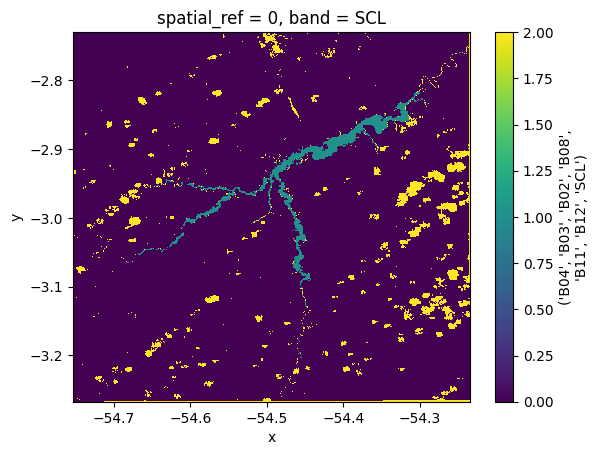

In [28]:
scl.isel(x=slice(None, None, 10), y=slice(None, None, 10)).plot()

### Sample points in each class

In [29]:
class_sample_size = {0: 100, 2: 100, 1: 100}  # Example sizes for each class

In [30]:
scl_df = scl.to_dataframe(name="class").reset_index().dropna(subset="class")

In [31]:
df_samp = gpd.GeoDataFrame()
for class_id, size in class_sample_size.items():
    class_samples = scl_df[scl_df["class"] == class_id].sample(n=size, random_state=42)
    df_samp = pd.concat([df_samp, class_samples])

In [32]:
df_samp = df_samp.set_geometry(gpd.points_from_xy(df_samp.x, df_samp.y))

<Axes: >

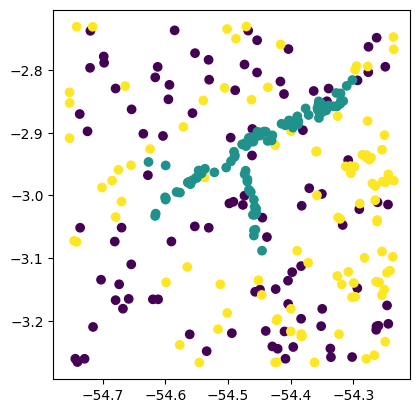

In [33]:
df_samp.plot(column="class")

In [34]:
df_samp.to_parquet("/data/swot/geotiffs/points/s2_curua-una-20240927T135701_samples.parquet", index=False)

### Create NDWI and MNDWI

In [35]:
img_dataset = img.to_dataset("band")

In [36]:
img_dataset["ndwi"] = (img_dataset["B03"] - img_dataset["B08"]) / (img_dataset["B03"] + img_dataset["B08"])
img_dataset["mndwi"] = (img_dataset["B03"] - img_dataset["B11"]) / (img_dataset["B03"] + img_dataset["B11"])


In [37]:
img = img_dataset.to_array(dim="band").squeeze()
# img

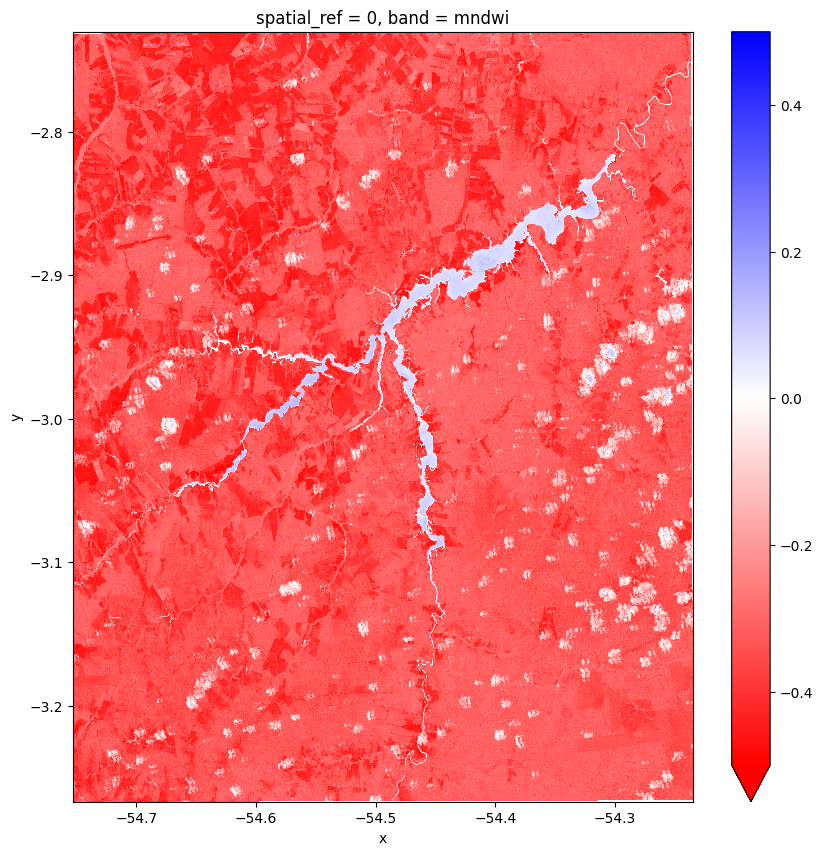

In [38]:
img.sel(band="mndwi").plot.imshow(cmap="bwr_r", vmin=-0.5, vmax=0.5, figsize=(10, 10))

### Sample the Radiometry in each Point

In [39]:
samples = img.sel(x=df_samp.x.values, y=df_samp.y.values, method="nearest")
samples

<xarray.DataArray (band: 8, y: 300, x: 300)> Size: 3MB
array([[[ 0.1293    ,  0.131     ,  0.1324    , ...,  0.1991    ,
          0.1429    ,  0.1372    ],
        [ 0.1332    ,  0.1752    ,  0.1446    , ...,  0.1766    ,
          0.165     ,  0.2098    ],
        [ 0.1472    ,  0.1398    ,  0.1359    , ...,  0.1367    ,
          0.4046    ,  0.1311    ],
        ...,
        [ 0.2566    ,  0.1386    ,  0.1353    , ...,  0.1538    ,
          0.5284    ,  0.1523    ],
        [ 0.3216    ,  0.1431    ,  0.1576    , ...,  0.1378    ,
          0.136     ,  0.1495    ],
        [ 0.2876    ,  0.1732    ,  0.1825    , ...,  0.294     ,
          0.1534    ,  0.1397    ]],

       [[ 0.151     ,  0.1552    ,  0.1598    , ...,  0.1796    ,
          0.1593    ,  0.1623    ],
        [ 0.1574    ,  0.1858    ,  0.1602    , ...,  0.1846    ,
          0.1568    ,  0.1978    ],
        [ 0.1572    ,  0.1596    ,  0.1618    , ...,  0.1528    ,
          0.3994    ,  0.1586    ],
...
        [-0.25472313,  0.05758784, -0.46182558, ...,  0.07563587,
         -0.07249324, -0.4268314 ],
        [-0.25058544, -0.4392324 , -0.39140022, ..., -0.46344733,
          0.04172767, -0.3959122 ],
        [-0.23379174, -0.09156748, -0.23695128, ..., -0.17063941,
         -0.39974645,  0.01452281]],

       [[-0.30510816, -0.30372363, -0.2989691 , ..., -0.36882794,
         -0.2980833 , -0.30551985],
        [-0.32228202, -0.30320644, -0.34222952, ..., -0.35657027,
         -0.37179488, -0.39612278],
        [-0.28529215, -0.33830848, -0.31075615, ..., -0.3295305 ,
         -0.20183855, -0.31755593],
        ...,
        [-0.3498153 ,  0.06608249, -0.2830018 , ...,  0.0858108 ,
         -0.04181978, -0.40369296],
        [-0.44214424, -0.37256458, -0.36503068, ..., -0.34264585,
          0.05720651, -0.33830848],
        [-0.28655428, -0.27152038, -0.23911148, ..., -0.13598737,
         -0.33036977, -0.03072352]]], shape=(8, 300, 300), dtype=float32)
Coordinates:
  * x            (x) float64 2kB -54.42 -54.5 -54.49 ... -54.54 -54.32 -54.47
  * y            (y) float64 2kB -3.245 -3.013 -3.22 ... -2.965 -2.837 -2.961
    spatial_ref  int64 8B 0
  * band         (band) object 64B 'B04' 'B03' 'B02' ... 'B12' 'ndwi' 'mndwi'

In [40]:
# Convert the samples to a dataframe and set x, y as index
samples_df = samples.to_dataframe(name="radi")#.unstack("band")
samples_df = samples_df.reset_index().set_index(["x", "y"]).drop(columns=["spatial_ref"])
samples_df

,,band,radi
x,y,,
-54.420725,-3.244779,B04,0.129300
-54.497803,-3.244779,B04,0.131000
-54.493836,-3.244779,B04,0.132400
-54.453449,-3.244779,B04,0.148500
-54.552614,-3.244779,B04,0.180000
...,...,...,...
-54.390344,-2.960716,mndwi,-0.293539
-54.599582,-2.960716,mndwi,-0.412295
-54.542337,-2.960716,mndwi,-0.135987


In [41]:
# Then, combine into a wide format DataFrame with bands as columns
radiometry = pd.DataFrame()

for band in samples_df["band"].unique():
    band_data = samples_df[samples_df["band"] == band].drop(columns=["band"])
    band_data = band_data.rename(columns = {"radi": band})
    radiometry = pd.concat([radiometry, band_data], axis=1)

# radiometry = radiometry.reset_index().set_index(["x", "y"])

radiometry

,,B04,B03,B02,B08,B11,B12,ndwi,mndwi
x,y,,,,,,,,
-54.420725,-3.244779,0.1293,0.1510,0.1320,0.4184,0.2836,0.1767,-0.469617,-0.305108
-54.497803,-3.244779,0.1310,0.1552,0.1330,0.4852,0.2906,0.1817,-0.515303,-0.303724
-54.493836,-3.244779,0.1324,0.1598,0.1354,0.4904,0.2961,0.1837,-0.508459,-0.298969
-54.453449,-3.244779,0.1485,0.1692,0.1359,0.4688,0.4208,0.2820,-0.469592,-0.426441
-54.552614,-3.244779,0.1800,0.1858,0.1596,0.4188,0.4012,0.2965,-0.385379,-0.366951
...,...,...,...,...,...,...,...,...,...
-54.390344,-2.960716,0.1424,0.1580,0.1378,0.4352,0.2893,0.1809,-0.467296,-0.293539
-54.599582,-2.960716,0.2554,0.2218,0.1907,0.4160,0.5330,0.3852,-0.304484,-0.412295
-54.542337,-2.960716,0.2940,0.2192,0.1736,0.3094,0.2882,0.2381,-0.170639,-0.135987


In [42]:
radiometry = radiometry.loc[~radiometry.index.duplicated(keep='first')]

In [43]:
df_samp = df_samp.set_index(["x", "y"])

In [44]:
radi_samples = radiometry.loc[df_samp.index]
radi_samples

,,B04,B03,B02,B08,B11,B12,ndwi,mndwi
x,y,,,,,,,,
-54.420725,-3.244779,0.1293,0.1510,0.1320,0.4184,0.2836,0.1767,-0.469617,-0.305108
-54.497803,-3.012823,0.1752,0.1858,0.1640,0.3896,0.3475,0.2244,-0.354188,-0.303206
-54.493836,-3.219897,0.1359,0.1618,0.1349,0.4600,0.3077,0.1932,-0.479575,-0.310756
-54.453449,-2.752470,0.1348,0.1602,0.1354,0.4584,0.2921,0.1838,-0.482056,-0.291621
-54.552614,-2.773024,0.2598,0.2332,0.1969,0.3866,0.4804,0.3120,-0.247499,-0.346413
...,...,...,...,...,...,...,...,...,...
-54.390344,-2.881204,0.1502,0.1579,0.1461,0.1436,0.1372,0.1299,0.047430,0.070146
-54.599582,-3.006783,0.1638,0.1690,0.1546,0.1458,0.2020,0.1650,0.073698,-0.088949
-54.542337,-2.965044,0.1538,0.1607,0.1463,0.1381,0.1353,0.1275,0.075636,0.085811


## Create Water Mask - Train Classifier

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.svm import SVC

In [46]:
radi_samples["class"] = df_samp["class"]

In [47]:
radi_samples = radi_samples.dropna()

In [48]:
feature_cols = ['B04', 'B03', 'B02', 'B08', 'B11', 'B12', 'ndwi', 'mndwi']
X = radi_samples[feature_cols].values
y = radi_samples['class'].values

In [49]:
# 2. Split data into train/test (e.g. 70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42,
)

In [50]:
clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
y_pred = clf.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        70
           1       0.95      0.99      0.97        70
           2       0.98      0.75      0.85        60

    accuracy                           0.92       200
   macro avg       0.93      0.91      0.91       200
weighted avg       0.93      0.92      0.92       200



In [52]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       0.97      0.97      0.97        30
           2       0.96      0.85      0.90        27

    accuracy                           0.94        87
   macro avg       0.94      0.94      0.94        87
weighted avg       0.94      0.94      0.94        87



In [53]:
import joblib

joblib.dump(clf, "/data/swot/models/s2_curua-una_svm_model.pkl")

['/data/swot/models/s2_curua-una_svm_model.pkl']

In [57]:
reflectances["ndwi"] = (reflectances["B03"] - reflectances["B08"]) / (reflectances["B03"] + reflectances["B08"])
reflectances["mndwi"] = (reflectances["B03"] - reflectances["B11"]) / (reflectances["B03"] + reflectances["B11"])

In [58]:
prediction = clf.predict(reflectances.fillna(0).values)

In [ ]:
prediction = prediction.reshape(img.shape[1], img.shape[2])

In [63]:
prediction.shape

(5951, 5746)

In [82]:
pred_arr = img.sel(band="B04")

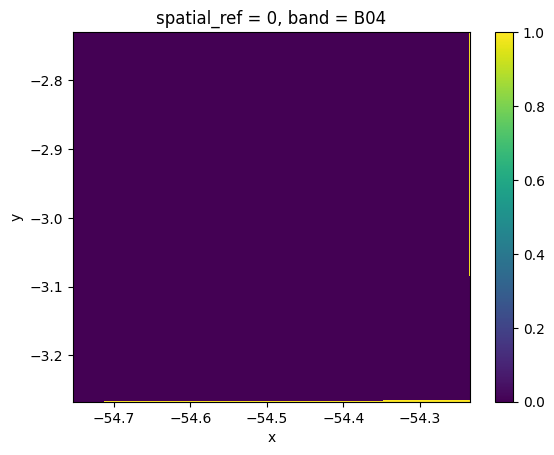

In [86]:
pred_arr.isel(x=slice(None, None, 10), y=slice(None, None, 10)).isnull().plot()

In [87]:
pred_img = pred_arr.where(pred_arr.isnull(), prediction)

In [90]:
pred_img = pred_img.fillna(2).astype("uint8")

In [91]:
pred_img.rio.to_raster(
    "/data/swot/geotiffs/s2_curua-una-20240927T135701_ref_mask.tif",
    compression="DEFLATE",
)

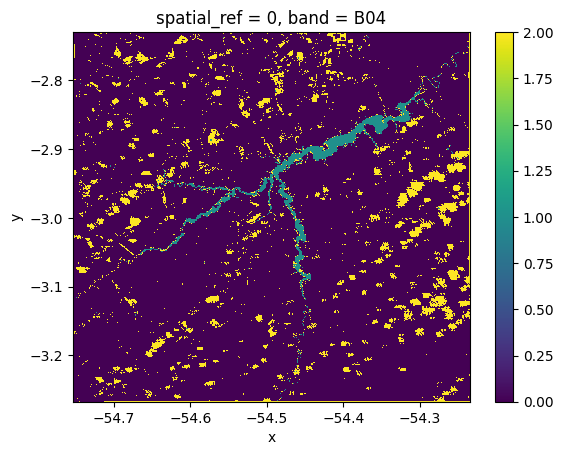

In [92]:
pred_img.isel(x=slice(None, None, 10), y=slice(None, None, 10)).plot.imshow()

# Scratch

In [10]:
from swot_toolkit.planetary import find_closest_s2, assess_s2_clouds, match_swot_s2

In [11]:
assess_s2_clouds(
    ref_time="2024-09-22",
    s2df=s2_df,
    aoi=AOI,
    max_days=15,
)

,datetime,tile,item,delta,valid_pxls
S2B_MSIL2A_20240922T135659_R067_T21MYS_20240922T194135,2024-09-22 13:56:59.024,21MYS,<Item id=S2B_MSIL2A_20240922T135659_R067_T21MY...,0 days 13:56:59.024000,0.137469


In [9]:
swot_s2 = match_swot_s2(
    swot_df=swot_df,
    s2_df=s2_df,
    aoi=AOI,
    max_days=5,
)

  0%|          | 0/158 [00:00<?, ?it/s]

KeyError: "None of ['index'] are in the columns"

In [ ]:
swot_s2

In [41]:
s2_df["datetime"] = pd.to_datetime(s2_df["datetime"]).dt.tz_localize(None)

In [42]:
s2_df["datetime"]

S2A_MSIL2A_20240101T135701_R067_T21MYS_20240101T191412   2024-01-01 13:57:01.024
S2B_MSIL2A_20240106T135659_R067_T21MYS_20240106T171445   2024-01-06 13:56:59.024
S2A_MSIL2A_20240111T135701_R067_T21MYS_20240111T191300   2024-01-11 13:57:01.024
S2B_MSIL2A_20240116T135659_R067_T21MYS_20240116T181414   2024-01-16 13:56:59.024
S2A_MSIL2A_20240121T135651_R067_T21MYS_20240121T191350   2024-01-21 13:56:51.024
                                                                   ...          
S2A_MSIL2A_20250606T140111_R067_T21MYS_20250606T185113   2025-06-06 14:01:11.024
S2B_MSIL2A_20250609T135659_R067_T21MYS_20250609T172547   2025-06-09 13:56:59.024
S2C_MSIL2A_20250614T135721_R067_T21MYS_20250614T191817   2025-06-14 13:57:21.025
S2A_MSIL2A_20250616T140101_R067_T21MYS_20250616T164918   2025-06-16 14:01:01.024
S2B_MSIL2A_20250619T135709_R067_T21MYS_20250619T174101   2025-06-19 13:57:09.024
Name: datetime, Length: 116, dtype: datetime64[ns]

In [43]:
find_closest_s2(
    ref_time=swot_df["datetime"].iloc[0],
    s2df=s2_df,
    max_days=5,
).head(3)

,datetime,tile,item,delta
S2B_MSIL2A_20240106T135659_R067_T21MYS_20240106T171445,2024-01-06 13:56:59.024,21MYS,<Item id=S2B_MSIL2A_20240106T135659_R067_T21MY...,1 days 06:31:30.024000
S2A_MSIL2A_20240101T135701_R067_T21MYS_20240101T191412,2024-01-01 13:57:01.024,21MYS,<Item id=S2A_MSIL2A_20240101T135701_R067_T21MY...,-4 days +06:31:32.024000


In [ ]:
import pandas as pd

pd.to_datetime(s2_df["datetime"])

S2A_MSIL2A_20240101T135701_R067_T21MYS_20240101T191412   2024-01-01 13:57:01.024000+00:00
S2B_MSIL2A_20240106T135659_R067_T21MYS_20240106T171445   2024-01-06 13:56:59.024000+00:00
S2A_MSIL2A_20240111T135701_R067_T21MYS_20240111T191300   2024-01-11 13:57:01.024000+00:00
S2B_MSIL2A_20240116T135659_R067_T21MYS_20240116T181414   2024-01-16 13:56:59.024000+00:00
S2A_MSIL2A_20240121T135651_R067_T21MYS_20240121T191350   2024-01-21 13:56:51.024000+00:00
                                                                       ...               
S2A_MSIL2A_20250606T140111_R067_T21MYS_20250606T185113   2025-06-06 14:01:11.024000+00:00
S2B_MSIL2A_20250609T135659_R067_T21MYS_20250609T172547   2025-06-09 13:56:59.024000+00:00
S2C_MSIL2A_20250614T135721_R067_T21MYS_20250614T191817   2025-06-14 13:57:21.025000+00:00
S2A_MSIL2A_20250616T140101_R067_T21MYS_20250616T164918   2025-06-16 14:01:01.024000+00:00
S2B_MSIL2A_20250619T135709_R067_T21MYS_20250619T174101   2025-06-19 13:57:09.024000+00:00
Name: date

In [29]:
swot_df

,cycle_id,pass_id,tile_id,date_str,tile_name,vers,item,datetime,date
short_id,,,,,,,,,
SWOT_L2_HR_PIXC_009_033_149R_20240105T072529,009,033,149R,20240105T072529,033_149R,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05
SWOT_L2_HR_PIXC_009_033_149L_20240105T072529,009,033,149L,20240105T072529,033_149L,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05
SWOT_L2_HR_PIXC_009_033_150R_20240105T072539,009,033,150R,20240105T072539,033_150R,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:39,2024-01-05
SWOT_L2_HR_PIXC_009_033_150L_20240105T072539,009,033,150L,20240105T072539,033_150L,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:39,2024-01-05
SWOT_L2_HR_PIXC_009_186_159R_20240110T183829,009,186,159R,20240110T183829,186_159R,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10
...,...,...,...,...,...,...,...,...,...
SWOT_L2_HR_PIXC_031_186_160R_20250413T191023,031,186,160R,20250413T191023,186_160R,PIC2,"{'meta': {'concept-type': 'granule', 'concept-...",2025-04-13 19:10:23,2025-04-13
SWOT_L2_HR_PIXC_032_033_149R_20250429T044218,032,033,149R,20250429T044218,033_149R,PIC2,"{'meta': {'concept-type': 'granule', 'concept-...",2025-04-29 04:42:18,2025-04-29
SWOT_L2_HR_PIXC_032_033_149L_20250429T044218,032,033,149L,20250429T044218,033_149L,PIC2,"{'meta': {'concept-type': 'granule', 'concept-...",2025-04-29 04:42:18,2025-04-29


In [21]:
import pystac_client

In [22]:
type(s2_df)

pystac.item_collection.ItemCollection

In [ ]:
s2_df.